# Day 1

In [17]:
from transformers import AutoTokenizer, AutoModel
import torch
import joblib

In [18]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(tokenizer.vocab_size)
print(tokenizer.model_max_length)

30522
512


In [19]:
text = "This movie was absolutely amazing!"
tokens = tokenizer(text)
print(tokens)

input_ids = tokens['input_ids']
print(len(input_ids))

decoded = tokenizer.decode(input_ids)
print(decoded)

{'input_ids': [101, 2023, 3185, 2001, 7078, 6429, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}
8
[CLS] this movie was absolutely amazing! [SEP]


In [20]:
def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

texts = [
    "This movie was great!",
    "Terrible movie, waste of time."
]

tokens = tokenize_texts(texts)
print(f'Shape: {tokens["input_ids"].shape}')
print(f'Attention mask:\n{tokens["attention_mask"]}')


Shape: torch.Size([2, 9])
Attention mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [21]:
print(f'CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})')
print(f'SEP token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})')
print(f'PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})')

CLS token: [CLS] (ID: 101)
SEP token: [SEP] (ID: 102)
PAD token: [PAD] (ID: 0)


In [22]:
single = tokenizer(text, return_tensors="pt")
print(f'Input IDs: {single["input_ids"]}')
print(f'Decoded: {tokenizer.decode(single["input_ids"][0])}')

Input IDs: tensor([[ 101, 2023, 3185, 2001, 7078, 6429,  999,  102]])
Decoded: [CLS] this movie was absolutely amazing! [SEP]


In [23]:
def explain_tokenization(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)
    print(f'Исходный текст: {text}')
    print(f'Токены: {tokens}')
    print(f'IDs: {ids}')
    print(f'Количество: {len(tokens)}')

explain_tokenization("Transformers are amazsgddsing!", tokenizer)

Исходный текст: Transformers are amazsgddsing!
Токены: ['transformers', 'are', 'ama', '##z', '##sg', '##dd', '##sing', '!']
IDs: [19081, 2024, 25933, 2480, 28745, 14141, 7741, 999]
Количество: 8


## Итог 1 дня

#### Почему нельзя использовать токенизатор от одной модели с весами другой?

потому что модель и токенизатор это согласованная пара.  внутри токенизатора есть словарь, в котором каждому id соответствует слово. а внутри модели есть embedding matrix, в которой содержатся числовые представления каждого id. и для каждой модели вектора слов совершенно разные и одинаковое слово будет иметь в разных моделях разный ID, соответственно и разный эмбеддинг

#### Что случится, если убрать attention_mask при батчевой обработке?

attention_mask нужна чтобы модель не принимала padding за настоящие слва. иначе модель будет считать как связан токен [PAD] c токеном 'amazing'. эмбеддинг всего предложения исказится.

#### Почему [CLS]-эмбеддинг подходит для классификации всего предложения?

это особенность механизма обучения BERT, модель вынуждена была делать из CLS-токена контекстное представление всего предложения, чтобы уменьшать loss на задаче NSP

#### Что произойдёт, если слово не встречается в словаре целиком?

слово будет разбито на несколько под-токенов, каждый из которых получит свой собственный эмбеддинг и пройдёт через модель как отдельный токен. через attention эти кусочки обмениваются контекстом друг с другом, но не объединяются в единый вектор явным образом.

# Day 2-4

In [24]:
model = AutoModel.from_pretrained(model_name)
model.eval()
print(model)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10644.90it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [25]:
text = "This movie was absolutely amazing!"
tokens = tokenizer(text, return_tensors='pt')


with torch.no_grad(): # без этой строчки pytorch будет расходовать память отслеживая все операции
    outputs = model(**tokens)

print(type(outputs))
print(outputs.last_hidden_state.shape)

<class 'transformers.modeling_outputs.BaseModelOutput'>
torch.Size([1, 8, 768])


In [26]:
def get_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        tokens = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**tokens)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
    import numpy as np
    return np.vstack(all_embeddings)

In [27]:
embeddings = get_embeddings(texts, tokenizer, model)
print(f'Embeddings shape: {embeddings.shape}')
# Ожидается: (4, 768)

Embeddings shape: (2, 768)


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2, tokenizer, model):
    emb = get_embeddings([text1, text2], tokenizer, model)
    sim = cosine_similarity(emb[0:1], emb[1:2])[0][0]
    return sim

sim1 = similarity("Great movie!", "Amazing film!", tokenizer, model)      # ожидаем высокое сходство
sim2 = similarity("Great movie!", "Terrible film!", tokenizer, model)     # ожидаем более низкое сходство

print(sim1)
print(sim2)

0.9954953
0.98384976


In [29]:
tokens = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    outputs = model(**tokens)

# Посмотри, что вообще лежит в последовательности
print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))
print(outputs.last_hidden_state.shape)  # [1, seq_len, 768]

# Эмбеддинг каждого отдельного токена (не только CLS)
for i, token in enumerate(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])):
    vec = outputs.last_hidden_state[0, i, :5]  # первые 5 чисел для наглядности
    print(f'{token}: {vec}')

['[CLS]', 'this', 'movie', 'was', 'absolutely', 'amazing', '!', '[SEP]']
torch.Size([1, 8, 768])
[CLS]: tensor([ 0.0682, -0.0685,  0.1918,  0.0139, -0.0544])
this: tensor([-0.1546, -0.4350,  0.1096,  0.1511,  0.6307])
movie: tensor([ 0.4407, -0.2312,  0.0390,  0.0697,  0.4034])
was: tensor([-0.0014, -0.5363, -0.0380,  0.1536,  0.0007])
absolutely: tensor([ 0.7613, -0.2543,  0.2118,  0.1066,  0.5234])
amazing: tensor([0.1686, 0.1280, 0.1475, 0.0134, 0.6005])
!: tensor([ 0.1401, -0.1907,  0.1083, -0.4105, -0.0063])
[SEP]: tensor([ 1.0056,  0.1261, -0.2686,  0.5711, -0.4132])


In [30]:
text = "This movie was amazing!"
tokens = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    outputs = model(**tokens)

print(outputs.last_hidden_state.shape)  # [1, N, 768]

# Посмотрим, что за токены у нас есть
words = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
print(words)  # ['[CLS]', 'this', 'movie', 'was', 'amazing', '!', '[SEP]']

# У каждого токена - свой вектор из 768 чисел
for i, w in enumerate(words):
    vec = outputs.last_hidden_state[0][i]
    print(f"{w}: первые 3 числа = {vec[:3].tolist()}")

torch.Size([1, 7, 768])
['[CLS]', 'this', 'movie', 'was', 'amazing', '!', '[SEP]']
[CLS]: первые 3 числа = [0.030219003558158875, -0.09791480004787445, 0.1608048528432846]
this: первые 3 числа = [-0.18913118541240692, -0.4656068682670593, 0.11609487235546112]
movie: первые 3 числа = [0.4147370755672455, -0.22497038543224335, -0.006167856976389885]
was: первые 3 числа = [-0.05229564011096954, -0.5216837525367737, -0.01282163243740797]
amazing: первые 3 числа = [0.1391555815935135, 0.16390414535999298, 0.1366458237171173]
!: первые 3 числа = [0.0016287036705762148, -0.31052523851394653, 0.05160004645586014]
[SEP]: первые 3 числа = [1.0233312845230103, 0.1334046721458435, -0.2713989317417145]


In [31]:
# Задание 3

# 1
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

texts = [
    "This movie was absolutely amazing, I loved every minute!",
    "Terrible movie, complete waste of time.",
    "Pretty good, I liked the plot and acting.",
    "Boring and way too long, I almost fell asleep.",
    "One of the best films I've seen this year!",
    "Awful. The worst movie experience of my life.",
    "Great performances and a solid story.",
    "I would not recommend this to anyone.",
    "A masterpiece, truly captivating from start to finish.",
    "Disappointing, the plot made no sense at all.",
    "Wonderful cinematography and a touching story.",
    "So bad it was almost funny, but mostly just bad.",
    "Loved it! Will definitely watch again.",
    "Not worth the ticket price, honestly.",
    "Brilliant acting, I was moved to tears.",
    "Painfully slow and poorly written.",
    "An instant classic, highly recommended!",
    "I regret watching this, total letdown.",
    "Fantastic movie with a great soundtrack.",
    "Mediocre at best, nothing special here."
]

labels = [
    1, 0, 1, 0, 1,
    0, 1, 0, 1, 0,
    1, 0, 1, 0, 1,
    0, 1, 0, 1, 0
]


model_name = 'distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

texts = ['ejieijr rieirtoie wejeir',
         'uhgirjoiejfiehrg jvdijosjr rejn enejr erkj']

tokens = tokenize_texts(texts)

print(tokens)

# 2
model = AutoModel.from_pretrained(model_name)
model.eval()


{'input_ids': tensor([[  101,  1041,  4478,  7416,  3501,  2099, 15544,  7416,  5339, 10448,
          2063,  2057,  6460,  4313,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0],
        [  101,  7910,  5856,  2099,  5558,  2666,  3501,  8873, 11106, 10623,
          1046, 16872, 28418,  2891,  3501,  2099,  2128, 22895,  4372, 20518,
          2099,  9413,  2243,  3501,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]])}


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11239.06it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=Tru

In [32]:
# 2
model = AutoModel.from_pretrained(model_name)
model.eval()

def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        tokens = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt')
        with torch.no_grad():
            outputs = model(**tokens)
        cls_embeddings = outputs.last_hidden_state[:, 0,:]
        all_embeddings.append(cls_embeddings.cpu().numpy())
    return np.vstack(all_embeddings)

dataset = load_dataset('stanfordnlp/imdb')
df = pd.DataFrame(dataset['train'])
df = df.sample(1000, random_state=42)

X = get_cls_embeddings(df['text'].tolist())
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
 
logreg = LogisticRegression(max_iter=1000, n_jobs=-1)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred, average='macro')

joblib.dump(logreg, 'baseline_model.pkl')


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10835.75it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/polina/ITpath/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.79      0.81      0.80       102
           1       0.80      0.78      0.79        98

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



['baseline_model.pkl']

In [33]:
with open("baseline_results.txt", "w") as f:
    f.write(f"Baseline (no fine-tuning) results\n")
    f.write(f"Model: {model_name}\n")
    f.write(f"Macro F1: {f1:.4f}\n\n")
    f.write(classification_report(y_test, y_pred))

# Day 5

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # ВАЖНО: не from transformers — устаревший импорт там
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
 
 
# =========================================================
# ЗАДАЧА 1: Dataset класс
# =========================================================
class SentimentDataset(Dataset):
    """
    Оборачивает тексты и метки в объект, совместимый с PyTorch DataLoader.
    Токенизация происходит ЛЕНИВО — по одному примеру за раз (см. __getitem__),
    а не для всего списка текстов сразу, как в Днях 1-4.
    """
 
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
 
    def __len__(self):
        # Сколько всего примеров в датасете
        return len(self.texts)
 
    def __getitem__(self, idx):
        # Достаёт и токенизирует ОДИН конкретный пример по индексу idx
        text = self.texts[idx]
        label = self.labels[idx]
 
        encoding = self.tokenizer(
            text,
            padding='max_length',   # дополняем до фиксированной длины (не до самого длинного в батче!)
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
 
        return {
            # .flatten() убирает лишнюю batch-размерность (была [1, 128], станет [128])
            # DataLoader сам добавит размерность батча при сборке
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }
 
 
# =========================================================
# ЗАДАЧА 2: Загрузка и подготовка данных
# =========================================================
 
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
 
from datasets import load_dataset
 
dataset = load_dataset("stanfordnlp/imdb")
df = pd.DataFrame(dataset['train'])
df = df.sample(1000, random_state=42)  # подвыборка для разумного времени обучения
 
texts = df['text'].tolist()
labels = df['label'].tolist()
 
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
 
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)
 
 
# =========================================================
# ЗАДАЧА 3: Модель для классификации + DataLoaders
# =========================================================
 
num_labels = len(set(labels))  
 
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
 
 
# =========================================================
# ЗАДАЧА 4: Оптимизатор и устройство (GPU/CPU)
# =========================================================
 
optimizer = AdamW(model.parameters(), lr=2e-5)
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Используется устройство: {device}")
 
 
# =========================================================
# ЗАДАЧА 5: Обучение одной эпохи
# =========================================================
 
def train_epoch(model, dataloader, optimizer, device):
    model.train()  # включаем dropout и т.п. — режим обучения
    total_loss = 0
 
    for batch in dataloader:
        optimizer.zero_grad()  # обнуляем градиенты от предыдущего батча
 
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['labels'].to(device)
 
        # Передаём labels — модель сама посчитает loss внутри себя
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels_batch
        )
 
        loss = outputs.loss
        loss.backward()   # считаем градиенты (backpropagation)
        optimizer.step()  # применяем градиенты — реально обновляем веса модели
 
        total_loss += loss.item()
 
    return total_loss / len(dataloader)
 
 
# =========================================================
# ЗАДАЧА 6: Оценка на валидации
# =========================================================
 
def evaluate(model, dataloader, device):
    model.eval()  # выключаем dropout — режим инференса
    predictions = []
    true_labels = []
 
    with torch.no_grad():  # градиенты не нужны, экономим память/время
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
 
            # labels НЕ передаём — нам нужны предсказания, а не loss
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
 
            preds = torch.argmax(outputs.logits, dim=1)  # индекс класса с макс. оценкой
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels_batch.cpu().numpy())
 
    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    return accuracy, f1
 
 
# =========================================================
# ЗАДАЧА 7: Цикл обучения по эпохам
# =========================================================
 
num_epochs = 3
val_acc, val_f1 = 0.0, 0.0  # на случай если понадобятся после цикла
 
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(model, val_loader, device)
 
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.4f}')
    print(f'Val F1: {val_f1:.4f}')
    print('-' * 50)
 
 
# =========================================================
# ЗАДАЧА 8: Сохранение модели и метрик
# =========================================================
 
model.save_pretrained('./fine_tuned_model')
tokenizer.save_pretrained('./fine_tuned_model')
 
with open('fine_tuned_results.txt', 'w') as f:
    f.write(f'Model: {model_name}\n')
    f.write(f'Epochs: {num_epochs}\n')
    f.write(f'Final Validation Accuracy: {val_acc:.4f}\n')
    f.write(f'Final Validation F1: {val_f1:.4f}\n')
 
print("Готово! Модель сохранена в ./fine_tuned_model")
print("Метрики сохранены в fine_tuned_results.txt")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9594.66it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Используется устройство: cpu
Epoch 1/3
Train Loss: 0.6091
Val Accuracy: 0.8250
Val F1: 0.8243
--------------------------------------------------
Epoch 2/3
Train Loss: 0.3305
Val Accuracy: 0.8400
Val F1: 0.8396
--------------------------------------------------
Epoch 3/3
Train Loss: 0.1774
Val Accuracy: 0.8300
Val F1: 0.8298
--------------------------------------------------


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.42it/s]

Готово! Модель сохранена в ./fine_tuned_model
Метрики сохранены в fine_tuned_results.txt


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11037.35it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Текст: This movie was absolutely fantastic!
Fine-tuned: 1 (probs: [0.03142178 0.9685782 ])
Baseline:   1
Совпадают: True

Текст: Terrible, waste of my time.
Fine-tuned: 0 (probs: [0.8215749  0.17842509])
Baseline:   1
Совпадают: False

Текст: It was okay, nothing special.
Fine-tuned: 1 (probs: [0.17948925 0.82051075])
Baseline:   1
Совпадают: True

Текст: Best film I've seen this year!
Fine-tuned: 1 (probs: [0.07214645 0.9278535 ])
Baseline:   1
Совпадают: True

Текст: Boring and too long.
Fine-tuned: 0 (probs: [0.88855803 0.11144196])
Baseline:   0
Совпадают: True


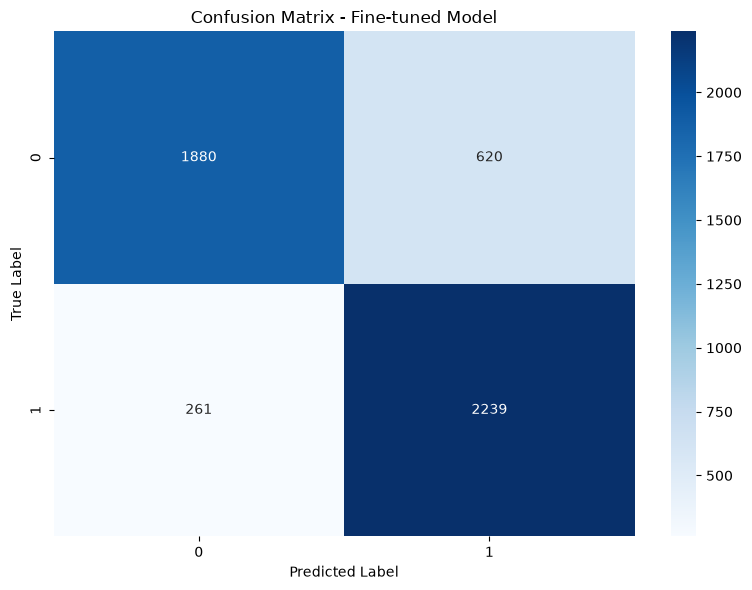

=== Fine-tuned Model ===
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      2500
           1       0.78      0.90      0.84      2500

    accuracy                           0.82      5000
   macro avg       0.83      0.82      0.82      5000
weighted avg       0.83      0.82      0.82      5000


=== Baseline Model ===
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2500
           1       0.80      0.78      0.79      2500

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000


=== Сравнение ===
Fine-tuned F1: 0.8229, Accuracy: 0.8238
Baseline F1: 0.7936, Accuracy: 0.7936
Улучшение F1: 3.70%

Готово! Результаты сохранены в comparison_results.txt


In [37]:
import torch
import joblib
import numpy as np
import pandas as pd
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    AutoModel
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
 
 
# =========================================================
# ЗАДАЧА 1: Загрузка моделей
# =========================================================
 
# --- Fine-tuned модель (из Дня 5) ---
model_ft = AutoModelForSequenceClassification.from_pretrained('./fine_tuned_model')
tokenizer_ft = AutoTokenizer.from_pretrained('./fine_tuned_model')
model_ft.eval()
 
# --- Baseline: тут вместо vectorizer.pkl используем tokenizer + AutoModel (как в Дне 4) ---
model_name = "distilbert-base-uncased"
embed_tokenizer = AutoTokenizer.from_pretrained(model_name)
embed_model = AutoModel.from_pretrained(model_name)
embed_model.eval()
 
baseline_model = joblib.load('baseline_model.pkl')  # обученная LogisticRegression из Дня 4
 
 
# =========================================================
# Вспомогательная функция — та же, что в Дне 2/4
# =========================================================
 
def get_cls_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        tokens = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=128, return_tensors="pt"
        )
        with torch.no_grad():
            outputs = model(**tokens)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
    return np.vstack(all_embeddings)
 
 
# =========================================================
# ЗАДАЧА 2: Предсказание для fine-tuned модели
# =========================================================
 
def predict_fine_tuned(texts, model, tokenizer):
    if isinstance(texts, str):
        texts = [texts]
 
    predictions = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
 
        with torch.no_grad():
            outputs = model(**inputs)
 
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
 
        predictions.append({
            'text': text,
            'prediction': pred,
            'probabilities': probs[0].cpu().numpy()
        })
 
    return predictions
 
 
# =========================================================
# ЗАДАЧА 3: Предсказание для baseline (эмбеддинги + LogReg)
# =========================================================
 
def predict_baseline(texts, model, tokenizer, embed_model):
    if isinstance(texts, str):
        texts = [texts]
 
    embeddings = get_cls_embeddings(texts, tokenizer, embed_model)
    predictions = model.predict(embeddings)
    probs = model.predict_proba(embeddings) if hasattr(model, 'predict_proba') else None
 
    results = []
    for i, text in enumerate(texts):
        results.append({
            'text': text,
            'prediction': int(predictions[i]),
            'probabilities': probs[i] if probs is not None else None
        })
 
    return results
 
 
# =========================================================
# ЗАДАЧА 4: Сравнение на примерах
# =========================================================
 
test_texts = [
    "This movie was absolutely fantastic!",
    "Terrible, waste of my time.",
    "It was okay, nothing special.",
    "Best film I've seen this year!",
    "Boring and too long."
]
 
preds_ft = predict_fine_tuned(test_texts, model_ft, tokenizer_ft)
preds_baseline = predict_baseline(test_texts, baseline_model, embed_tokenizer, embed_model)
 
for i, text in enumerate(test_texts):
    print(f'\nТекст: {text}')
    print(f'Fine-tuned: {preds_ft[i]["prediction"]} (probs: {preds_ft[i]["probabilities"]})')
    print(f'Baseline:   {preds_baseline[i]["prediction"]}')
    print(f'Совпадают: {preds_ft[i]["prediction"] == preds_baseline[i]["prediction"]}')
 
 
# =========================================================
# ЗАДАЧА 5: Confusion Matrix для fine-tuned модели
# =========================================================
 
dataset = load_dataset("stanfordnlp/imdb")
df = pd.DataFrame(dataset['train'])  # берём конкретно сплит 'train', конвертируем в DataFrame

_, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

test_texts_full = test_df['text'].tolist()
test_labels_full = test_df['label'].tolist()
 
preds_ft_all = predict_fine_tuned(test_texts_full, model_ft, tokenizer_ft)
y_pred_ft = [p['prediction'] for p in preds_ft_all]
 
cm_ft = confusion_matrix(test_labels_full, y_pred_ft)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Fine-tuned Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_finetuned.png')
plt.show()
 
 
# =========================================================
# ЗАДАЧА 6: Сравнение метрик baseline vs fine-tuned
# =========================================================
 
print("=== Fine-tuned Model ===")
print(classification_report(test_labels_full, y_pred_ft))
f1_ft = f1_score(test_labels_full, y_pred_ft, average='macro')
acc_ft = accuracy_score(test_labels_full, y_pred_ft)
 
preds_baseline_all = predict_baseline(test_texts_full, baseline_model, embed_tokenizer, embed_model)
y_pred_base = [p['prediction'] for p in preds_baseline_all]
 
print("\n=== Baseline Model ===")
print(classification_report(test_labels_full, y_pred_base))
f1_base = f1_score(test_labels_full, y_pred_base, average='macro')
acc_base = accuracy_score(test_labels_full, y_pred_base)
 
print(f'\n=== Сравнение ===')
print(f'Fine-tuned F1: {f1_ft:.4f}, Accuracy: {acc_ft:.4f}')
print(f'Baseline F1: {f1_base:.4f}, Accuracy: {acc_base:.4f}')
print(f'Улучшение F1: {(f1_ft - f1_base) / f1_base * 100:.2f}%')
 
 
# =========================================================
# ЗАДАЧА 7: Сохранение результатов сравнения
# =========================================================
 
with open('comparison_results.txt', 'w') as f:
    f.write('=== Сравнение моделей ===\n\n')
    f.write(f'Fine-tuned Model:\n')
    f.write(f'  F1 (macro): {f1_ft:.4f}\n')
    f.write(f'  Accuracy: {acc_ft:.4f}\n')
    f.write(f'\nBaseline Model:\n')
    f.write(f'  F1 (macro): {f1_base:.4f}\n')
    f.write(f'  Accuracy: {acc_base:.4f}\n')
    f.write(f'\nУлучшение: {(f1_ft - f1_base) / f1_base * 100:.2f}%\n')
 
print("\nГотово! Результаты сохранены в comparison_results.txt")
 

In [38]:
df_test = pd.DataFrame({
    'text': test_texts_full,
    'true_label': test_labels_full,
    'pred_label': y_pred_ft
})
 
errors = df_test[df_test['true_label'] != df_test['pred_label']]
 
# False Positives — модель сказала "позитив" (1), а на самом деле "негатив" (0)
fp = errors[(errors['pred_label'] == 1) & (errors['true_label'] == 0)]
 
# False Negatives — модель сказала "негатив" (0), а на самом деле "позитив" (1)
fn = errors[(errors['pred_label'] == 0) & (errors['true_label'] == 1)]
 
print(f'Всего ошибок: {len(errors)}')
print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')
 
 
# =========================================================
# ЗАДАЧА 2: Анализ паттернов ошибок
# =========================================================
 
print("\n=== FALSE POSITIVES (сказали positive, а было negative) ===")
for idx, row in fp.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')
 
print("\n=== FALSE NEGATIVES (сказали negative, а было positive) ===")
for idx, row in fn.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')
 
# Анализ длины ошибочных текстов
errors = errors.copy()  # чтобы избежать SettingWithCopyWarning от pandas
errors['text_length'] = errors['text'].str.len()
 
print(f'\nСредняя длина ошибочных текстов: {errors["text_length"].mean():.0f}')
print(f'Средняя длина всех текстов: {df_test["text"].str.len().mean():.0f}')
 
 
# =========================================================
# Сохранение анализа в файл
# =========================================================
 
with open('error_analysis.txt', 'w', encoding='utf-8') as f:
    f.write('=== АНАЛИЗ ОШИБОК ===\n\n')
    f.write(f'Всего ошибок: {len(errors)}\n')
    f.write(f'False Positives: {len(fp)}\n')
    f.write(f'False Negatives: {len(fn)}\n\n')
 
    f.write(f'Средняя длина ошибочных текстов: {errors["text_length"].mean():.0f}\n')
    f.write(f'Средняя длина всех текстов: {df_test["text"].str.len().mean():.0f}\n\n')
 
    f.write('=== ПРИМЕРЫ FALSE POSITIVES ===\n')
    for idx, row in fp.head(5).iterrows():
        f.write(f'\nТекст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')
 
    f.write('\n\n=== ПРИМЕРЫ FALSE NEGATIVES ===\n')
    for idx, row in fn.head(5).iterrows():
        f.write(f'\nТекст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')
 
    f.write('\n\n=== НАБЛЮДЕНИЯ ===\n')
    f.write('(Впиши сюда свои выводы после просмотра примеров выше — например:\n')
    f.write('- встречаются ли отрицания ("not bad", "wasn\'t great") в ошибочных текстах?\n')
    f.write('- есть ли сарказм/ирония, которую модель не улавливает?\n')
    f.write('- связаны ли ошибки с длиной текста?)\n')
 
print("\nГотово! Анализ сохранён в error_analysis.txt")

Всего ошибок: 881
False Positives: 620
False Negatives: 261

=== FALSE POSITIVES (сказали positive, а было negative) ===

Текст: The deceptive cover, title and very small hidden print of Power of Prayer tricked me into renting th...
Истинный класс: 0, Предсказан: 1

Текст: This movie tackles child abduction from the point of view of a Mom (lisa Hartman Black) who acts lik...
Истинный класс: 0, Предсказан: 1

Текст: This is exactly the sort of Saturday matinee serial I loved during World War II. I was under ten yea...
Истинный класс: 0, Предсказан: 1

Текст: As a casual listener of the Rolling Stones, I thought this might be interesting. Not so, as this fil...
Истинный класс: 0, Предсказан: 1

Текст: I watched this film in youth group, where my otherwise intuitive youth leader and his wife squeed ov...
Истинный класс: 0, Предсказан: 1

=== FALSE NEGATIVES (сказали negative, а было positive) ===

Текст: Any movie that shows federal PIGs (Persons In Government) to be the power-mad threats